# Traveling Salesperson Art

In [1]:
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
import skimage
from scipy.ndimage import distance_transform_edt
from scipy.spatial import Delaunay
from scipy import sparse
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.ndimage import gaussian_filter1d
from numba import jit

## Part 1: Stipple Pattern

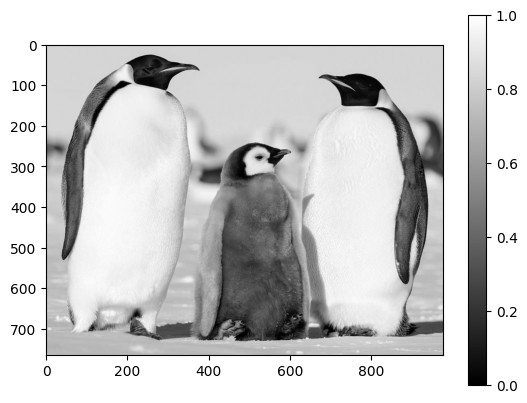

In [2]:
image = skimage.io.imread("images/penguins.png")
image = image.astype(float) / 255 # Remap to [0, 1]
image_grayscale = image[..., 0] * 0.2125 + image[..., 1] * 0.7154 + image[..., 2] * 0.0721
plt.imshow(image_grayscale, cmap='gray')
plt.colorbar()

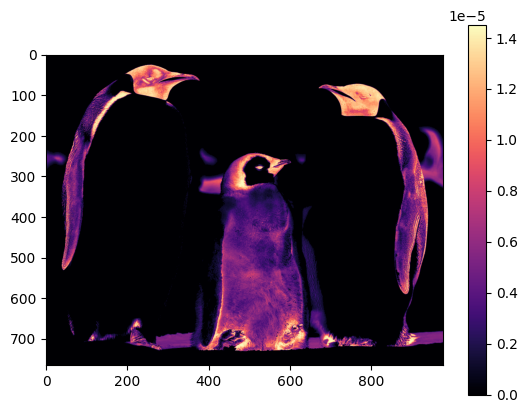

In [3]:
low_threshold = 0.4
contrast = 3
probability = 1 - image_grayscale
probability[probability < 0.4] = 0
probability = probability ** contrast
probability = probability / np.sum(probability)
plt.imshow(probability, cmap='magma')
plt.colorbar()

[350580 589188  26655 ... 661592  55047 696113]


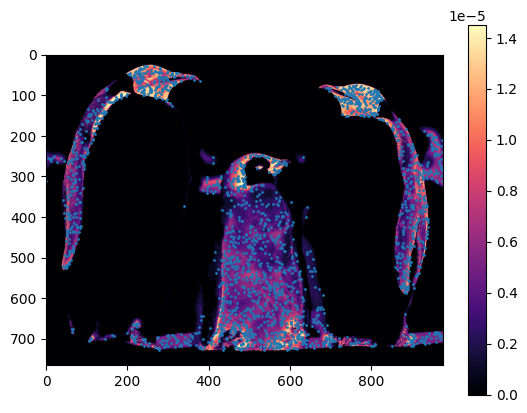

In [4]:
# Throw down n_samples numbers between 0 and 1, and determine the interval for each one
# To find the interval, do a binary search on cprobability
# Overall time complexity O(n_samples * log(n_pixels))
n_samples = 2000

cprobability = np.zeros(1+probability.size)
cprobability[1:] = np.cumsum(probability.flatten())

seed = 1
np.random.seed(seed)
indices = np.searchsorted(cprobability, np.random.rand(n_samples))
print(indices)
rows, columns = np.unravel_index(indices, probability.shape)

plt.imshow(probability, cmap='magma')
plt.colorbar()
plt.scatter(columns, rows, s=1)


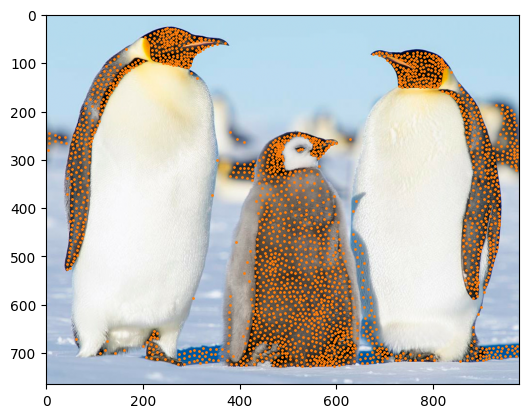

In [5]:
@jit(nopython=True)
def do_voronoi_iteration(n_sites, indices, probability):
    """
    Do one iteration of stipple refinement via weighted Voronoi centroids
    """
    numerator = np.zeros((n_sites, 2))
    denominator = np.zeros(n_sites)
    for i in range(indices.shape[0]):
        for j in range(indices.shape[1]):
            site_index = indices[i, j]
            weight = probability[i, j]
            numerator[site_index] += weight*np.array([i, j])
            denominator[site_index] += weight
    numerator = numerator[denominator > 0, :]
    denominator = denominator[denominator > 0]

    locations = numerator / denominator[:, None]
    rows, columns = locations[:, 0], locations[:, 1]
    rows = np.round(rows)
    rows[rows >= indices.shape[0]] = indices.shape[0]-1
    columns = np.round(columns)
    columns[columns >= indices.shape[1]] = indices.shape[1] - 1

    return rows, columns

def refine_stipple(rows: np.ndarray, columns: np.ndarray, 
                   probability: np.ndarray, n_iters: int = 10) -> tuple[np.ndarray, np.ndarray]:
    """
    Refine a stipple by doing multiple Voronoi iterations
    """
    for _ in range(n_iters):
        mask = np.ones((probability.shape[0], probability.shape[1]))
        mask[rows, columns] = 0
        _, indices = distance_transform_edt(mask, return_indices=True)
        index_row = indices[0, ...]
        index_column = indices[1, ...]
        indices = index_row * probability.shape[1] + index_column # An injective map from (i, j) -> i*n_columns + j
        unique_indices = np.unique(indices)
        n_sites = unique_indices.size
        index2index = np.zeros(indices.size)
        index2index[unique_indices] = np.arange(n_sites)
        indices = index2index[indices].astype(int)
        rows, columns = do_voronoi_iteration(n_sites, indices, probability)
        rows = rows.astype(int)
        columns = columns.astype(int)
    return rows, columns


def get_stipple(path: str, 
                n_samples: int, 
                low_threshold: float = 0.4, 
                contrast: float = 3,
                n_iters: int = 10,
                ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Parameters
    ----------
    path:
        Path to image file
    low_threshold:
        Probability below which to rule out pixels
    contrast: 
        Amount to stretch the contrast of bright regions
    n_iters:
        Number of iterations of Voronoi refinement to do
        
    Returns
    -------
    image, probabilities, rows, columns
    """
    ## Step 1: Convert to grayscale
    image = skimage.io.imread(path)
    image = image.astype(float) / 255 # Remap to [0, 1]
    image_grayscale = image[..., 0] * 0.2125 + image[..., 1] * 0.7154 + image[..., 2] * 0.0721
    ## Step 2: Create probabilities
    probability = 1 - image_grayscale
    probability[probability < low_threshold] = 0
    probability = probability ** contrast
    probability = probability / np.sum(probability)
    ## Step 3: Sample pixel locations proportionally to probabilities
    cprobability = np.zeros(1+probability.size)
    cprobability[1:] = np.cumsum(probability.flatten())
    indices = np.searchsorted(cprobability, np.random.rand(n_samples))
    rows, columns = np.unravel_index(indices, probability.shape)
    rows, columns = refine_stipple(rows, columns, probability, n_iters)
    return image, probability, rows, columns

image, probability, rows, columns = get_stipple("images/penguins.png", 2000, low_threshold=0.4, contrast=3)
plt.imshow(image)
plt.scatter(columns, rows, s=1, c='C1')

## Part 2: Traveling Salesperson

In [6]:
## Step 1: Build Delaunay Triangulation
stipple_pc = np.array([rows, columns]).T
triangulation = Delaunay(stipple_pc) 
tris = triangulation.simplices
edges = set([])
for tri in tris:
    for i in range(3):
        e1, e2 = [tri[i], tri[(i+1)%3]]
        edges.add((e1, e2))
        edges.add((e2, e1))
edges = list(edges)
edges = np.array(edges, dtype=int)


In [7]:
## Step 2: Construct Minimum Spanning Tree of the Triangulation
dV = stipple_pc[edges[:, 1]] - stipple_pc[edges[:, 0]] # Vector between each edge endpoint
distances_sqr = np.sum(dV**2, axis=1)
distances_sqr[distances_sqr < 0] = 0
distances = np.sqrt(distances_sqr)
n_stipple = len(rows)

adjacency = sparse.coo_matrix((distances, (edges[:, 0], edges[:, 1])), shape = (n_stipple, n_stipple))
mst = minimum_spanning_tree(adjacency)

In [8]:
mst = mst.tocoo()
edges_mst = np.array([mst.row, mst.col], dtype=int).T

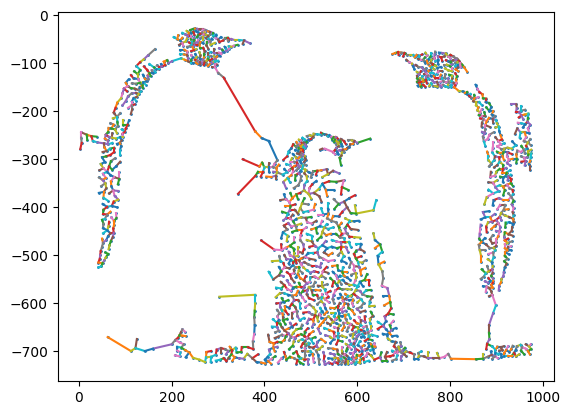

In [9]:
plt.scatter(columns, -rows, s=1)
for [i, j] in edges_mst:
    plt.plot(columns[[i, j]], -rows[[i, j]])

In [10]:
print(edges.shape, edges_mst.shape)

(11846, 2) (1985, 2)


In [11]:
## Step 3: Do DFS traversal of MST
### Setup vertex neighbor adjacency structure
vertex_neighbors = {}
for [i, j] in edges_mst:
    if not i in vertex_neighbors:
        vertex_neighbors[i] = set()
    if not j in vertex_neighbors:
        vertex_neighbors[j] = set()
    vertex_neighbors[i].add(j)
    vertex_neighbors[j].add(i)

### Do depth-first search
frontier = [0] # Stack representing vertices that are "on fire"
visited = set()
on_frontier = set([0])
order = []
while len(frontier) > 0:
    vertex_index = frontier.pop() # DFS takes off the *back* of frontier
    on_frontier.remove(vertex_index)
    visited.add(vertex_index)
    order.append(vertex_index)
    for neighbor_index in vertex_neighbors[vertex_index]:
        if not neighbor_index in on_frontier and not neighbor_index in visited:
            frontier.append(neighbor_index)
            on_frontier.add(neighbor_index)
order.append(order[0])

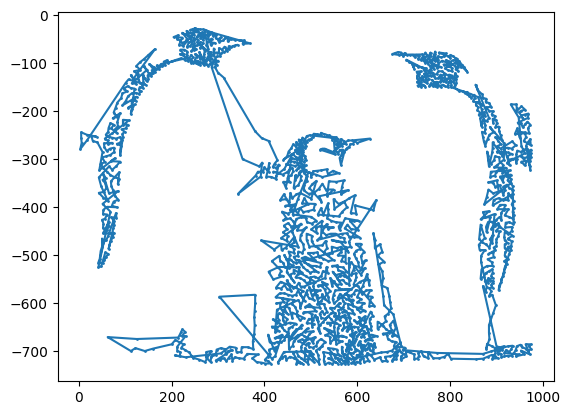

In [12]:
order = np.array(order, dtype=int)
stipple_order = stipple_pc[order]
plt.scatter(stipple_order[:, 1], -stipple_order[:, 0], s=1)
plt.plot(stipple_order[:, 1], -stipple_order[:, 0])

In [13]:
@jit(nopython=True)
def get_crossing_indices(order, stipple_pc, i_last):
    N = len(order)
    for i in list(range(i_last, N-1)) + list(range(0, i_last)):
        for j in range(i+1, N-1):
            a = stipple_pc[order[i]] - stipple_pc[order[j]]
            a = np.sqrt(np.sum(a**2))
            b = stipple_pc[order[i+1]] - stipple_pc[order[j+1]]
            b = np.sqrt(np.sum(b**2))
            c = stipple_pc[order[i]] - stipple_pc[order[i+1]]
            c = np.sqrt(np.sum(c**2))
            d = stipple_pc[order[j]] - stipple_pc[order[j+1]]
            d = np.sqrt(np.sum(d**2))
            if a + b < c + d:
                return i, j
    return None

plt.figure(figsize=(10, 10))
i_last = 0
for it in range(10000):            
    result = get_crossing_indices(order, stipple_pc, i_last)
    if result is None:
        break
    (i, j) = result
    i_last = i
    # print(i, j)
    order = np.concatenate((order[0:i+1], order[i+1:j+1][::-1], order[j+1:]))
    order = np.array(order, dtype=int)
    stipple_order = stipple_pc[order]
    # plt.clf()
    # plt.scatter(stipple_order[:, 1], -stipple_order[:, 0], s=1)
    # plt.plot(stipple_order[:, 1], -stipple_order[:, 0])
    # plt.savefig(f"Frame{it}.png")

<Figure size 1000x1000 with 0 Axes>

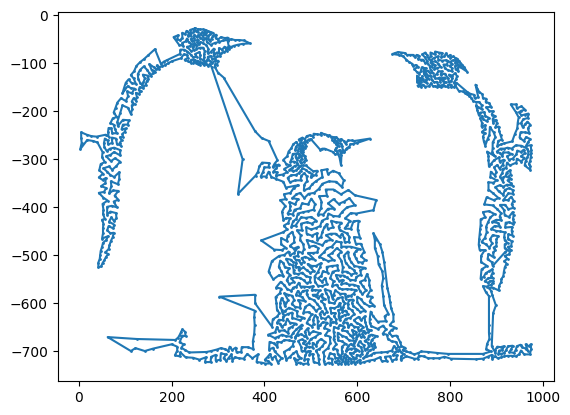

In [14]:
plt.scatter(stipple_order[:, 1], -stipple_order[:, 0], s=1)
plt.plot(stipple_order[:, 1], -stipple_order[:, 0])
plt.savefig(f"Seed{seed}.png")

### Re-Parameterize Curve

In [15]:
len(stipple_order)

1987

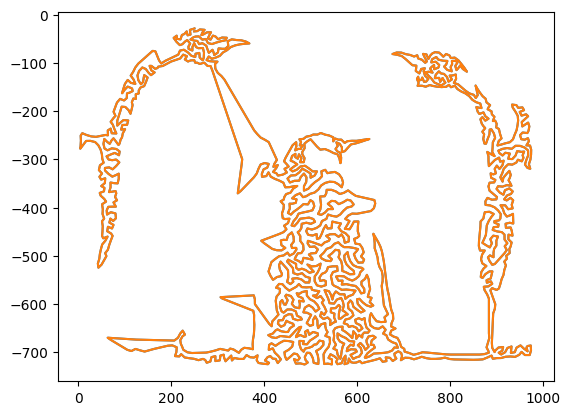

In [16]:
def resample_loop(original, t):
    """
    Resample a loop according to some normalized arclength parameter

    Parameters
    ----------
    original: np.ndarray(N, 2)
        N points on an original loop
    t: np.ndarray(M)
        M samples in [0, 1] in monotonically increasing order
    
    Returns
    -------
    ndarray(M, 2)
        The resampled curve
    """
    loop = np.concatenate((original, original[0:1]), axis=0)
    vector = loop[1:] - loop[0:-1]
    lengths = np.sum(vector**2, axis=1)
    lengths[lengths < 0] = 0
    lengths = np.sqrt(lengths)
    arclengths = np.zeros(len(lengths)+1)
    arclengths[1:] = np.cumsum(lengths)

    resampled = np.zeros((len(t), 2))
    for d in range(loop.shape[1]):
        resampled[:, d] = np.interp(t*arclengths[-1], arclengths, loop[:, d])
    
    return resampled

n_new_points = 2000
t = np.linspace(0, 1, n_new_points+1)[0:-1]
stipple_resampled = resample_loop(stipple_order, t)
plt.plot(stipple_resampled[:, 1], -stipple_resampled[:, 0])
plt.plot(stipple_resampled[:, 1], -stipple_resampled[:, 0])

### Curvature-Shrinking Flow

In [17]:
sigma = 2

n_new_points = 2000
t = np.linspace(0, 1, n_new_points+1)[0:-1]
stipple_smoothed = stipple_order.copy()

plt.figure(figsize=(10, 10))
# for it in range(10000):
#     stipple_resampled = resample_loop(stipple_smoothed, t, sigma)
#     stipple_smoothed = gaussian_filter1d(stipple_smoothed, sigma, axis=0, mode='wrap')
#     plt.clf()
#     plt.scatter(stipple_smoothed[:, 1], -stipple_smoothed[:, 0], s=1)
#     plt.plot(stipple_smoothed[:, 1], -stipple_smoothed[:, 0])
#     plt.title(f"Curvature Shrinking Smoothing Iteration {it}, $\\sigma = {sigma}$")
#     plt.xlim([0, np.max(stipple_order[:, 1])])
#     plt.ylim([-np.max(stipple_order[:, 0]), 0])
#     plt.savefig(f"Smooth{it}.png")

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

### TSP Tunes

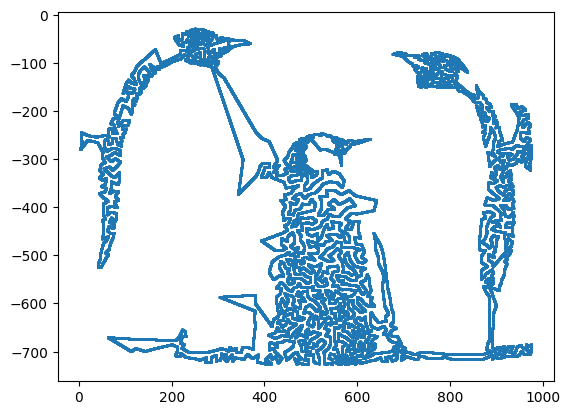

In [18]:
sr = 44100
freq = 220 # cycles / sec
n_seconds = 2
t = np.linspace(0, n_seconds * freq, sr*n_seconds) % 1
y = resample_loop(stipple_order, t)

plt.scatter(y[:, 1], -y[:, 0], s=1)
ipd.Audio(y.T, rate=sr)

### Fun with Fourier

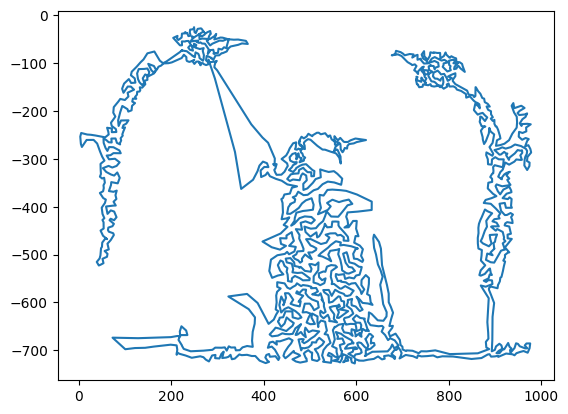

In [37]:
y = stipple_order[:, 0] + 1j * stipple_order[:, 1]
fourier = np.fft.fft(y)
mag = np.abs(fourier)
q = np.quantile(mag, 0.5)
fourier[mag < q] = 0
yinv = np.fft.ifft(fourier)
plt.plot(np.imag(yinv), -np.real(yinv))